# Task 2 (Intermediate) – Decision Tree Classifier

**Goal:** Classify Iris flower species using a pruned Decision Tree, then visualise the decision rules.

**Why pruning?**  
An unpruned tree will memorise the training data (overfitting). Capping `max_depth=3` forces the model to learn only the most important splits, making it more generalisable — and much easier to visualise.

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

## 1. Load Data

In [2]:
iris = sns.load_dataset('iris')
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 2. Split into Train & Test Sets

In [3]:
X = iris.drop('species', axis=1)
y = iris['species']

# 70/30 split — a bit more training data helps the tree learn clear boundaries
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 105  |  Test: 45


## 3. Train the Decision Tree

We use **entropy** as the splitting criterion (measures information gain). `max_depth=3` keeps the tree readable and reduces overfitting.

In [4]:
clf = DecisionTreeClassifier(
    max_depth=3,
    criterion='entropy',   # entropy = information gain; alternative is 'gini'
    random_state=42
)
clf.fit(X_train, y_train)

print("Tree depth used:", clf.get_depth())
print("Number of leaves:", clf.get_n_leaves())

Tree depth used: 3
Number of leaves: 5


## 4. Evaluate

In [5]:
y_pred = clf.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9778

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



## 5. Visualise the Tree

This is one of the nicest things about Decision Trees — you can literally read the rules the model learned.

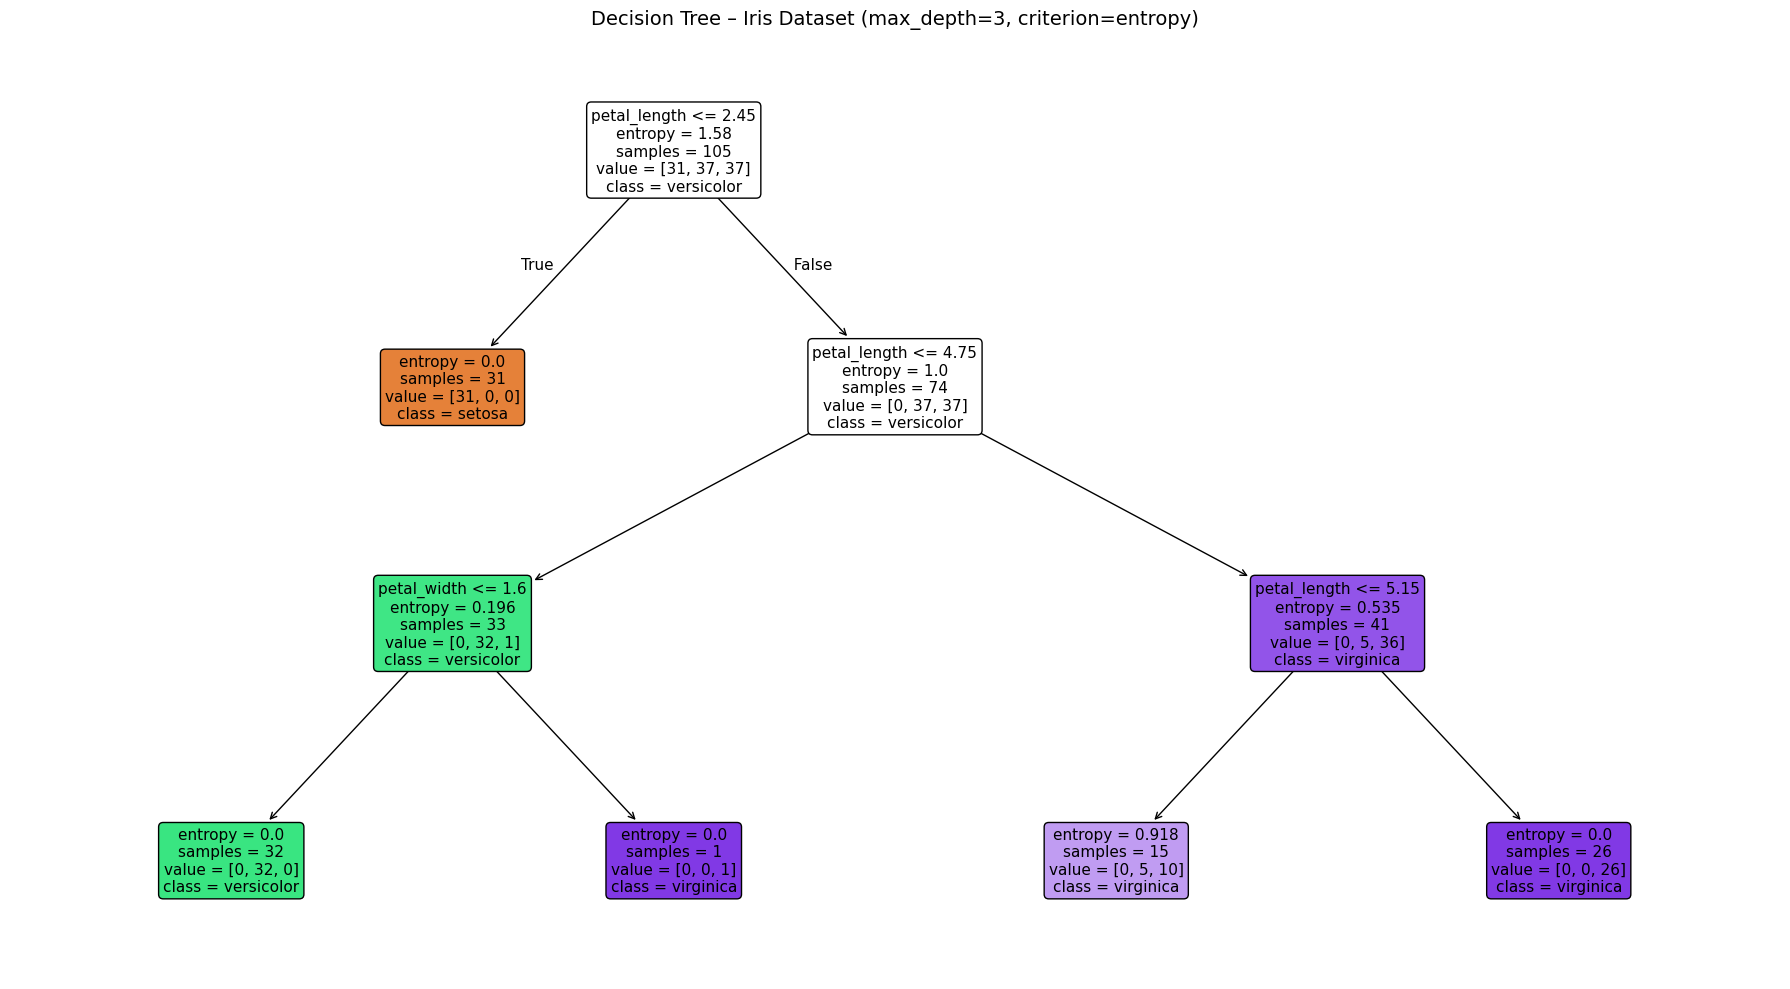

In [6]:
plt.figure(figsize=(18, 10))
plot_tree(
    clf,
    feature_names=X.columns,
    class_names=clf.classes_,
    filled=True,
    rounded=True,
    fontsize=11
)
plt.title("Decision Tree – Iris Dataset (max_depth=3, criterion=entropy)", fontsize=14)
plt.tight_layout()
plt.show()